# Stage 1 — Dataset Generation

This notebook generates the received signals and the ordered sequence of
\(K\) covariance matrices for the CNN–LSTM spectrum-sensing framework.

The CNN input is obtained only by averaging the same covariance sequence:

$$
X_{\mathrm{CNN}}
=
\frac{1}{K}\sum_{k=0}^{K-1} C_k.
$$

This notebook does not perform dataset splitting, model training, hyperparameter
selection, or testing.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch


# Controls reproducibility of dataset generation only.
DATASET_SEED = 42

print("NumPy version:", np.__version__)

NumPy version: 2.5.1


## 1. Physical Scenario and Covariance Configuration

The same dataset-generation functions will support:

- Scenario 1: one secondary user with \(M\) antennas;
- Scenario 2: \(Q\) distributed single-antenna secondary users.

For each sensing slot, block vectors of length $D_c$ are used to construct one
$D_c\times D_c$ sample covariance matrix.

In [2]:
# Select one physical scenario for the current dataset-generation run.
PHYSICAL_SCENARIO = "multi_antenna"
# Alternative: PHYSICAL_SCENARIO = "multi_su"

# Number of receivers in the two physical scenarios.
M = 6   # Number of antennas in Scenario 1
Q = 6   # Number of distributed SUs in Scenario 2

# Sensing-period parameters.
# Fixed total sample budget.
TOTAL_TIME_SAMPLES = 12000

# Planned manual K experiments: 5, 10, 12, 15, and 20.
# Change K manually and regenerate the dataset for each experiment.
K = 10  # Number of sensing slots

if TOTAL_TIME_SAMPLES % K != 0:
    raise ValueError(
        "TOTAL_TIME_SAMPLES must be divisible by K."
    )

N = TOTAL_TIME_SAMPLES // K  # Number of temporal samples in each slot

# Covariance block-vector parameters.
L = 2               # Smoothing factor / block length
BLOCK_SHIFT = 2     # Shift between consecutive block vectors

if not 1 <= L <= N:
    raise ValueError(
        "L must satisfy 1 <= L <= N."
    )

if BLOCK_SHIFT <= 0:
    raise ValueError(
        "BLOCK_SHIFT must be positive."
    )


if PHYSICAL_SCENARIO == "multi_antenna":
    NUM_RECEIVERS = M
elif PHYSICAL_SCENARIO == "multi_su":
    NUM_RECEIVERS = Q
else:
    raise ValueError(
        "PHYSICAL_SCENARIO must be 'multi_antenna' or 'multi_su'."
    )

# Covariance-matrix dimension.
D_C = NUM_RECEIVERS * L

# Number of block vectors constructed within every sensing slot.
B = ((N - L) // BLOCK_SHIFT) + 1 # // --> floor operation after division (floor division)

print("Physical scenario       :", PHYSICAL_SCENARIO)
print("Number of receivers     :", NUM_RECEIVERS)
print("Number of sensing slots :", K)
print("Samples per slot        :", N)
print("Covariance dimension    :", D_C)
print("Blocks per slot         :", B)

Physical scenario       : multi_antenna
Number of receivers     : 6
Number of sensing slots : 10
Samples per slot        : 1200
Covariance dimension    : 12
Blocks per slot         : 600


## 2. Temporal Conditions

Three temporal conditions are considered:

1. **Fading-varying condition:** the noise power is fixed, while the small-scale
   fading coefficient evolves across the $K$ sensing slots.

2. **Noise-power-varying condition:** the noise power varies across the $K$
   sensing slots. A new fading coefficient is generated for every realization,
   but that coefficient remains fixed across all $K$ slots of the realization.

3. **Joint-varying condition:** both the noise power and the small-scale fading
   coefficient vary across the $K$ sensing slots.

For a given experiment, the large-scale fading power-variance profile $\boldsymbol{\beta}$ remains fixed across slots and realizations.
Its entries are identical for the co-located antennas in Scenario 1, but may be group-dependent for the distributed SUs in Scenario 2.
Only the small-scale fading realizations change.

The listed noise-power values define a set of possible slotwise powers, not a
fixed increasing temporal profile. For every realization, their order is newly
randomized. If $K$ exceeds the number of available values, some values are
repeated before randomization.

In [3]:
# Temporal correlation coefficient for fading-varying trajectories.
RHO = 0.5

# Scenario 1: common fading variance used by all co-located antennas.
# Each value defines a separate ROC experiment.
SCENARIO1_FADING_VARIANCE_DB_GRID = np.array(
    [-10, -11, -12, -13, -14, -15],
    dtype=float
)

# Case 1: fading varies across slots, while noise power is fixed.
FIXED_NOISE_POWER_FADING_VARYING = 80.0

# Case 2: noise power varies across slots.
# Scenario 1 noise-power-varying condition:
# the fading value is redrawn for every realization but fixed over K slots.
SCENARIO1_FIXED_FADING_VARIANCE_DB_NOISE_VARYING = -10.0

# Scenario 2: six SUs arranged into three location groups.
# SUs with the same group ID share the same large-scale variance.
SCENARIO2_SU_GROUP_IDS = np.array(
    [0, 0, 1, 1, 2, 2],
    dtype=int
)

NUM_SCENARIO2_GROUPS = 3

NOISE_POWER_SETS = {
    "noise_100_190": np.arange(100, 200, 10, dtype=float),
    "noise_200_290": np.arange(200, 300, 10, dtype=float),
    "noise_300_390": np.arange(300, 400, 10, dtype=float),
    "noise_400_490": np.arange(400, 500, 10, dtype=float),
    "noise_500_590": np.arange(500, 600, 10, dtype=float),
    "noise_600_690": np.arange(600, 700, 10, dtype=float),
}

# Case 3: both fading and noise power vary across slots.
JOINT_NOISE_POWER_SET = np.array(
    [90, 96, 102, 108, 114, 120, 126, 132, 138, 144],
    dtype=float
)

# Basic configuration checks.
assert 0.0 <= RHO < 1.0

for set_name, power_values in NOISE_POWER_SETS.items():
    assert len(power_values) > 0
    assert np.all(power_values > 0)

assert len(JOINT_NOISE_POWER_SET) > 0
assert np.all(JOINT_NOISE_POWER_SET > 0)

assert SCENARIO2_SU_GROUP_IDS.shape == (Q,)

assert np.array_equal(
    np.unique(SCENARIO2_SU_GROUP_IDS),
    np.arange(NUM_SCENARIO2_GROUPS)
)


print(
    "Scenario 1 fading-variance grid:",
    SCENARIO1_FADING_VARIANCE_DB_GRID
)

print(
    "Scenario 1 fixed fading variance for "
    "noise-power-varying case:",
    SCENARIO1_FIXED_FADING_VARIANCE_DB_NOISE_VARYING,
    "dB"
)

print(
    "Scenario 2 SU group IDs:",
    SCENARIO2_SU_GROUP_IDS
)

print(
    "Fixed noise power for fading-varying case:",
    FIXED_NOISE_POWER_FADING_VARYING
)


print("\nNoise-power-varying sets:")
for set_name, power_values in NOISE_POWER_SETS.items():
    print(set_name, ":", power_values)

print("\nJoint noise-power set:", JOINT_NOISE_POWER_SET)

Scenario 1 fading-variance grid: [-10. -11. -12. -13. -14. -15.]
Scenario 1 fixed fading variance for noise-power-varying case: -10.0 dB
Scenario 2 SU group IDs: [0 0 1 1 2 2]
Fixed noise power for fading-varying case: 80.0

Noise-power-varying sets:
noise_100_190 : [100. 110. 120. 130. 140. 150. 160. 170. 180. 190.]
noise_200_290 : [200. 210. 220. 230. 240. 250. 260. 270. 280. 290.]
noise_300_390 : [300. 310. 320. 330. 340. 350. 360. 370. 380. 390.]
noise_400_490 : [400. 410. 420. 430. 440. 450. 460. 470. 480. 490.]
noise_500_590 : [500. 510. 520. 530. 540. 550. 560. 570. 580. 590.]
noise_600_690 : [600. 610. 620. 630. 640. 650. 660. 670. 680. 690.]

Joint noise-power set: [ 90.  96. 102. 108. 114. 120. 126. 132. 138. 144.]


## 3. Conversion of Fading Power Variance from dB to Linear Scale

The fading parameter specified in dB represents a power variance:

$$
\beta_{\mathrm{dB}} = 10\log_{10}(\beta).
$$

Therefore, its linear-domain value is

$$
\beta = 10^{\beta_{\mathrm{dB}}/10}.
$$

The real-valued small-scale fading coefficient is subsequently generated as

$$
h \sim \mathcal{N}(0,\beta),
$$

so its standard deviation is $\sqrt{\beta}$.

In [4]:
def power_db_to_linear(power_db):
    """
    Convert a power quantity from dB to linear scale.

    Parameters
    ----------
    power_db : float or array-like
        Power value or values expressed in dB.

    Returns
    -------
    ndarray
        Corresponding power values in linear scale.
    """
    power_db = np.asarray(power_db, dtype=float)
    return 10.0 ** (power_db / 10.0)


scenario1_fading_variance_linear_grid = power_db_to_linear(
    SCENARIO1_FADING_VARIANCE_DB_GRID
)

print(
    "Scenario 1 fading variance in dB:",
    SCENARIO1_FADING_VARIANCE_DB_GRID
)

print(
    "Scenario 1 fading variance in linear scale:",
    scenario1_fading_variance_linear_grid
)

Scenario 1 fading variance in dB: [-10. -11. -12. -13. -14. -15.]
Scenario 1 fading variance in linear scale: [0.1        0.07943282 0.06309573 0.05011872 0.03981072 0.03162278]


## 4. PU Signal and Frequency-Band Configuration

Three real-valued band-limited PU signals are considered:

- PU1: lower adjacent-band interferer;
- PU2: target PU that defines $H_0$ and $H_1$;
- PU3: upper adjacent-band interferer.

The hypotheses are

$$
H_0:\ \text{PU2 is absent},
$$

and

$$
H_1:\ \text{PU2 is present}.
$$

PU1 and PU3 may be present under both hypotheses and must not determine the
class label.

In [5]:
# Variance of the unfiltered real Gaussian sequence used to generate each PU.
# Because the source bandpass filter has approximately unit passband gain,
# this sets the nominal in-band PU PSD level to 80.
# It does not represent the total integrated power of the filtered PU signal.
# For a normalized bandwidth of 0.15, the filtered-signal variance is
# approximately 80 * 0.15 = 12.
UNFILTERED_PU_VARIANCE = 80.0

# PU frequency bands in radians/sample.
PU_BANDS = {
    "PU1": (0.10 * np.pi, 0.25 * np.pi),
    "PU2": (0.40 * np.pi, 0.55 * np.pi),
    "PU3": (0.70 * np.pi, 0.85 * np.pi),
}

# Target receiver passband corresponding to PU2.
RECEIVER_BAND = (
    0.398 * np.pi,
    0.552 * np.pi
)

# Odd filter lengths selected for centered FIR implementation.
# The value 501 remains smaller than N for all planned K experiments.
SOURCE_FILTER_LENGTH = 501
RECEIVER_FILTER_LENGTH = 501

# Basic checks.
assert TOTAL_TIME_SAMPLES == K * N
assert UNFILTERED_PU_VARIANCE > 0

for pu_name, (lower_frequency, upper_frequency) in PU_BANDS.items():
    assert 0 < lower_frequency < upper_frequency < np.pi

receiver_lower, receiver_upper = RECEIVER_BAND
assert 0 < receiver_lower < receiver_upper < np.pi

print("Total temporal samples:", TOTAL_TIME_SAMPLES)
print("Unfiltered PU variance:", UNFILTERED_PU_VARIANCE)

print("\nPU bands normalized by pi:")
for pu_name, band in PU_BANDS.items():
    print(
        pu_name,
        ":",
        np.asarray(band) / np.pi
    )

print(
    "\nReceiver band normalized by pi:",
    np.asarray(RECEIVER_BAND) / np.pi
)

Total temporal samples: 12000
Unfiltered PU variance: 80.0

PU bands normalized by pi:
PU1 : [0.1  0.25]
PU2 : [0.4  0.55]
PU3 : [0.7  0.85]

Receiver band normalized by pi: [0.398 0.552]


## 5. Sinc-Based Bandpass Filter

In this notebook, the normalized sinc convention used by NumPy is adopted:

$$
\operatorname{sinc}(x)
=
\frac{\sin(\pi x)}{\pi x}.
$$

The ideal discrete-time low-pass filter has an infinite-duration impulse
response. For numerical implementation, it is truncated to a finite number of
coefficients and centered at $n_c$.


$$
h_{\mathrm{LP}}[n]
=
\frac{\theta}{\pi}
\operatorname{sinc}
\left(
\frac{\theta(n-n_c)}{\pi}
\right),
$$

where $n_c$ is the center of the finite impulse response.

For a filter of length $P$,

$$
n=0,1,\ldots,P-1,
\qquad
n_c=\frac{P-1}{2}.
$$

A bandpass filter with lower and upper cutoff frequencies
$\theta_1$ and $\theta_2$ is obtained by subtracting two low-pass filters:

$$
h_{\mathrm{BP}}[n]
=
\frac{\theta_2}{\pi}
\operatorname{sinc}
\left(
\frac{\theta_2(n-n_c)}{\pi}
\right)
-
\frac{\theta_1}{\pi}
\operatorname{sinc}
\left(
\frac{\theta_1(n-n_c)}{\pi}
\right).
$$

An odd filter length is used so that $n_c$ corresponds exactly to the middle
sample.

No additional window is applied, consistent with the student notebook.
Consequently, finite truncation may produce passband and stopband ripples.

In [6]:
def create_sinc_bpf(
    lower_frequency,
    upper_frequency,
    filter_length
):
    """
    Construct a real-valued sinc-based FIR bandpass filter.

    Parameters
    ----------
    lower_frequency : float
        Lower cutoff frequency in radians/sample.

    upper_frequency : float
        Upper cutoff frequency in radians/sample.

    filter_length : int
        Number of FIR coefficients. It must be a positive odd integer.

    Returns
    -------
    ndarray
        One-dimensional array containing the FIR coefficients.
    """
    if not 0 < lower_frequency < upper_frequency < np.pi:
        raise ValueError(
            "The cutoff frequencies must satisfy "
            "0 < lower_frequency < upper_frequency < pi."
        )

    if filter_length <= 0 or filter_length % 2 == 0:
        raise ValueError(
            "filter_length must be a positive odd integer."
        )

    sample_indices = np.arange(filter_length, dtype=float)
    center_index = (filter_length - 1) / 2.0
    shifted_indices = sample_indices - center_index

    bandpass_filter = (
        (upper_frequency / np.pi)
        * np.sinc(
            upper_frequency * shifted_indices / np.pi
        )
        -
        (lower_frequency / np.pi)
        * np.sinc(
            lower_frequency * shifted_indices / np.pi
        )
    )

    return bandpass_filter

In [7]:
pu2_source_filter = create_sinc_bpf(
    lower_frequency=PU_BANDS["PU2"][0],
    upper_frequency=PU_BANDS["PU2"][1],
    filter_length=SOURCE_FILTER_LENGTH
)

receiver_filter = create_sinc_bpf(
    lower_frequency=RECEIVER_BAND[0],
    upper_frequency=RECEIVER_BAND[1],
    filter_length=RECEIVER_FILTER_LENGTH
)

assert pu2_source_filter.shape == (SOURCE_FILTER_LENGTH,)
assert receiver_filter.shape == (RECEIVER_FILTER_LENGTH,)

assert np.all(np.isfinite(pu2_source_filter))
assert np.all(np.isfinite(receiver_filter))

assert np.allclose(
    pu2_source_filter,
    pu2_source_filter[::-1]
)

assert np.allclose(
    receiver_filter,
    receiver_filter[::-1]
)

print("PU2 source-filter shape:", pu2_source_filter.shape)
print("Receiver-filter shape  :", receiver_filter.shape)

print(
    "PU2 center coefficient :",
    pu2_source_filter[SOURCE_FILTER_LENGTH // 2]
)

print(
    "Receiver center coefficient:",
    receiver_filter[RECEIVER_FILTER_LENGTH // 2]
)

PU2 source-filter shape: (501,)
Receiver-filter shape  : (501,)
PU2 center coefficient : 0.15000000000000002
Receiver center coefficient: 0.15399999999999997


### 5.1 Frequency-Response Diagnostic

The frequency responses of the source and receiver filters are inspected before
they are used to generate the dataset.

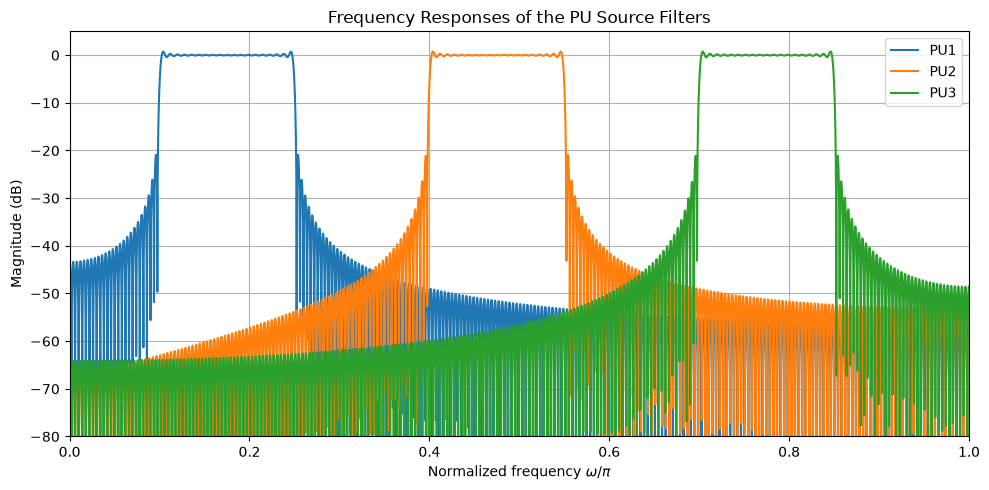

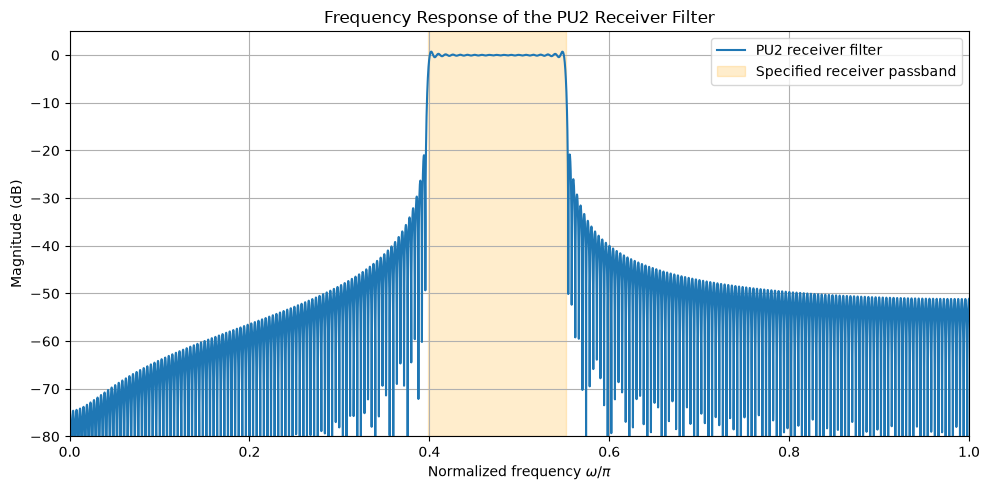

In [8]:
def compute_frequency_response_db(
    filter_coefficients,
    fft_length=16384
):
    """
    Compute the one-sided magnitude response of a real FIR filter.

    Parameters
    ----------
    filter_coefficients : array-like
        FIR filter coefficients.

    fft_length : int
        Number of frequency points used by the FFT.

    Returns
    -------
    normalized_frequency : ndarray
        Frequencies normalized by pi, ranging from 0 to 1.

    magnitude_db : ndarray
        Magnitude response expressed in dB.
    """
    frequency_response = np.fft.rfft(
        filter_coefficients,
        n=fft_length
    )

    normalized_frequency = np.linspace(
        0.0,
        1.0,
        len(frequency_response)
    )

    magnitude_db = 20.0 * np.log10(
        np.maximum(
            np.abs(frequency_response),
            1e-12
        )
    )

    return normalized_frequency, magnitude_db


# Construct the three source filters explicitly.
source_filters = {}

for pu_name, band in PU_BANDS.items():
    lower_cutoff = band[0]
    upper_cutoff = band[1]

    # Keyword arguments make the parameter mapping explicit and
    # prevent accidental argument-order errors.
    filter_coefficients = create_sinc_bpf(
        lower_frequency=lower_cutoff,
        upper_frequency=upper_cutoff,
        filter_length=SOURCE_FILTER_LENGTH
    )
    
    source_filters[pu_name] = filter_coefficients


# Plot the three PU source-filter responses.
plt.figure(figsize=(10, 5))

for pu_name, filter_coefficients in source_filters.items():
    normalized_frequency, magnitude_db = (
        compute_frequency_response_db(
            filter_coefficients
        )
    )

    plt.plot(
        normalized_frequency,
        magnitude_db,
        label=pu_name
    )

plt.xlabel(r"Normalized frequency $\omega/\pi$")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Responses of the PU Source Filters")
plt.xlim(0.0, 1.0)
plt.ylim(-80, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Compute the PU2 receiver-filter response.
receiver_frequency, receiver_magnitude_db = (
    compute_frequency_response_db(
        receiver_filter
    )
)


# Plot the PU2 receiver-filter response.
plt.figure(figsize=(10, 5))

plt.plot(
    receiver_frequency,
    receiver_magnitude_db,
    label="PU2 receiver filter"
)

plt.axvspan(
    RECEIVER_BAND[0] / np.pi,
    RECEIVER_BAND[1] / np.pi,
    color="orange",
    alpha=0.2,
    label="Specified receiver passband"
)

plt.xlabel(r"Normalized frequency $\omega/\pi$")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Response of the PU2 Receiver Filter")
plt.xlim(0.0, 1.0)
plt.ylim(-80, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Generation of Independent Band-Limited PU Signals

For each PU, an independent real-valued white Gaussian signal is generated as

$$
u_i[n]\sim\mathcal{N}(0,\sigma_u^2),
\qquad i\in\{1,2,3\}.
$$

The corresponding band-limited PU waveform is obtained by filtering:

$$
z_i[n] = f_i[n] * u_i[n],
$$

where $f_i[n]$ is the source bandpass filter associated with the frequency
band of the \(i\)-th PU.

PU1, PU2, and PU3 are generated from independent Gaussian sequences. PU2 is the
target signal, whereas PU1 and PU3 are adjacent-band interferers.

Additional input samples are generated before filtering so that valid
convolution produces the required number of output samples without zero-padding
transients at the signal boundaries.

In [9]:
def generate_bandlimited_pu(
    rng,
    filter_coefficients,
    num_output_samples,
    unfiltered_variance
):
    """
    Generate one independent real-valued band-limited PU waveform.

    Parameters
    ----------
    rng : numpy.random.Generator
        Random-number generator used for reproducibility.

    filter_coefficients : array-like
        FIR source-filter coefficients.

    num_output_samples : int
        Required number of band-limited output samples.

    unfiltered_variance : float
        Variance of the unfiltered white Gaussian input.

    Returns
    -------
    ndarray
        Real-valued band-limited PU waveform.
    """
    filter_coefficients = np.asarray(
        filter_coefficients,
        dtype=float
    )

    if filter_coefficients.ndim != 1:
        raise ValueError(
            "filter_coefficients must be one-dimensional."
        )

    if num_output_samples <= 0:
        raise ValueError(
            "num_output_samples must be positive."
        )

    if unfiltered_variance <= 0:
        raise ValueError(
            "unfiltered_variance must be positive."
        )

    filter_length = len(filter_coefficients)

    # Generate enough input samples so that valid convolution
    # produces exactly num_output_samples samples.
    num_input_samples = (
        num_output_samples
        + filter_length
        - 1
    )

    unfiltered_signal = rng.normal(
        loc=0.0,
        scale=np.sqrt(unfiltered_variance),
        size=num_input_samples
    )

    bandlimited_signal = np.convolve(
        unfiltered_signal,
        filter_coefficients,
        mode="valid"
    )

    if len(bandlimited_signal) != num_output_samples:
        raise RuntimeError(
            "Unexpected band-limited signal length."
        )

    return bandlimited_signal

In [10]:
diagnostic_rng = np.random.default_rng(DATASET_SEED)

diagnostic_pu_signals = {}

for pu_name, filter_coefficients in source_filters.items():
    pu_signal = generate_bandlimited_pu(
        rng=diagnostic_rng,
        filter_coefficients=filter_coefficients,
        num_output_samples=TOTAL_TIME_SAMPLES,
        unfiltered_variance=UNFILTERED_PU_VARIANCE
    )

    diagnostic_pu_signals[pu_name] = pu_signal


for pu_name, pu_signal in diagnostic_pu_signals.items():
    print(
        pu_name,
        "| shape:", pu_signal.shape,
        "| mean:", np.mean(pu_signal),
        "| variance:", np.var(pu_signal)
    )

PU1 | shape: (12000,) | mean: 0.0008239660867414742 | variance: 12.340659290794642
PU2 | shape: (12000,) | mean: 0.0003489713961539268 | variance: 11.956117724932641
PU3 | shape: (12000,) | mean: -4.991076856608734e-05 | variance: 11.732065398990281


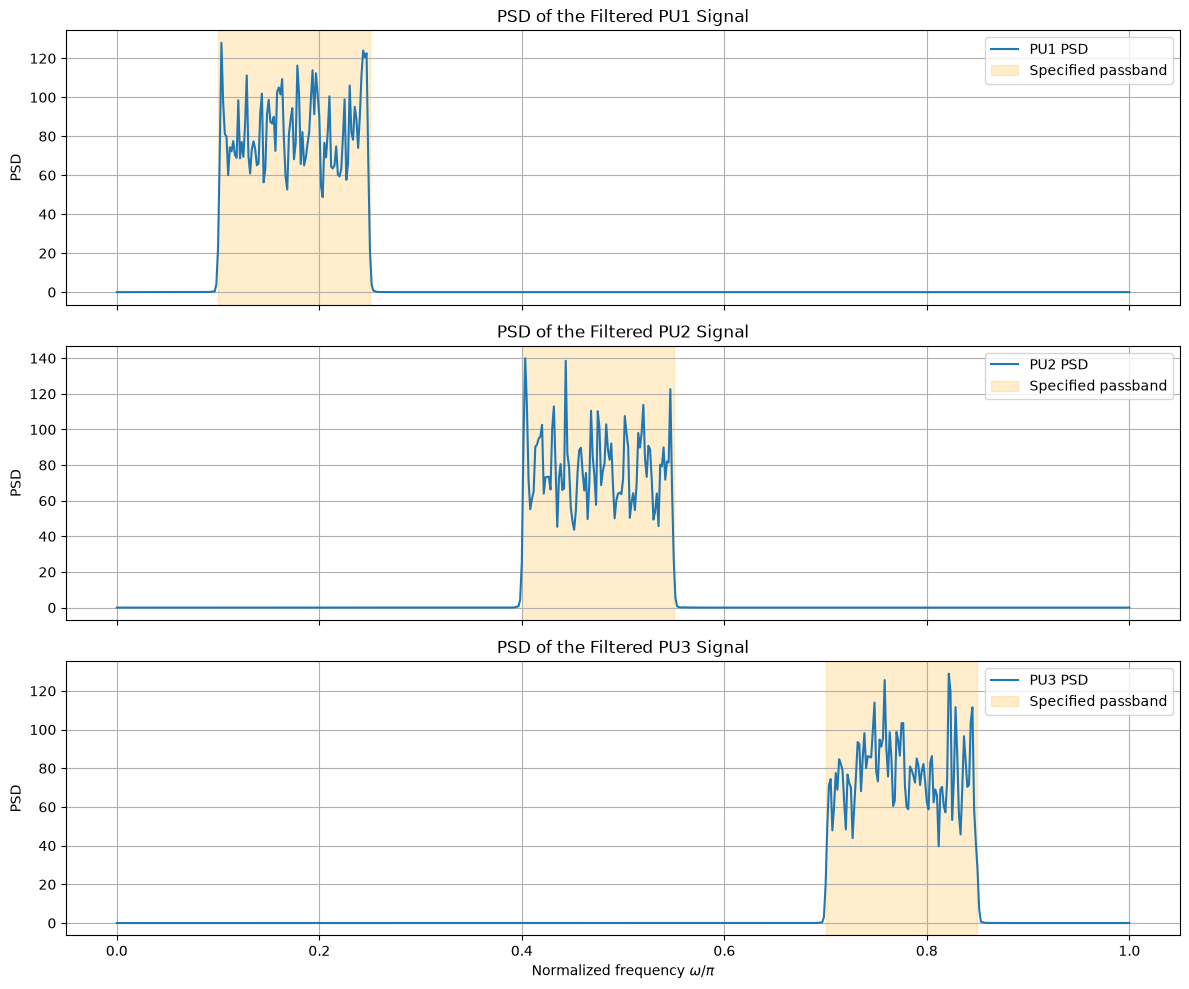

In [11]:
figure, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 10),
    sharex=True
)

for axis, (pu_name, pu_signal) in zip(
    axes,
    diagnostic_pu_signals.items()
):
    normalized_frequency, psd = welch(
        pu_signal,
        fs=2.0,
        nperseg=1200,
        noverlap=600,
        detrend=False,
        scaling="density"
    )

    lower_frequency = PU_BANDS[pu_name][0] / np.pi
    upper_frequency = PU_BANDS[pu_name][1] / np.pi

    axis.plot(
        normalized_frequency,
        psd,
        label=f"{pu_name} PSD"
    )

    axis.axvspan(
        lower_frequency,
        upper_frequency,
        color="orange",
        alpha=0.2,
        label="Specified passband"
    )

    axis.set_title(
        f"PSD of the Filtered {pu_name} Signal"
    )

    axis.set_ylabel("PSD")
    axis.grid(True)
    axis.legend()

axes[-1].set_xlabel(
    r"Normalized frequency $\omega/\pi$"
)

plt.tight_layout()
plt.show()

## 7. Generation of Real-Valued Fading Coefficients

Let $a_{i,r}[k]$ denote the real-valued channel coefficient from PU $i$ to receiver $r$ during sensing slot $k$. In Scenario 1, the receivers are the $M$ antennas of one SU. In Scenario 2, they are the $Q$ distributed single-antenna SUs.

Let $\beta_r$ denote the large-scale fading power variance associated with receiver $r$. This variance represents the effects of path loss
and shadowing and remains fixed across all $K$ sensing slots and all realizations of a given experiment.

To simplify the simulation, the large-scale fading variance associated with a particular receiver is assumed to be the same for PU1, PU2, and PU3. Therefore, the variance depends on the receiver index $r$, but not on the PU index $i$:

$$
\operatorname{Var}\{a_{1,r}[k]\}
=
\operatorname{Var}\{a_{2,r}[k]\}
=
\operatorname{Var}\{a_{3,r}[k]\}
=
\beta_r.
$$

This assumption concerns only the large-scale fading variance. The
actual small-scale fading coefficients of the three PU-to-receiver
links are generated independently.

In Scenario 1, all antennas are co-located and therefore use the same
large-scale fading variance:

$$
\beta_r=\beta,
\qquad r=0,1,\ldots,M-1.
$$

Although the antennas share the same variance, their actual small-scale fading coefficients are generated independently.

In Scenario 2, the distributed SUs may be divided into location groups. SUs in the same group use the same large-scale fading variance, whereas SUs in different groups may use different variances. For example, for three groups containing two SUs each,

$$
\boldsymbol{\beta}
=
[\beta_0,\beta_0,\beta_1,\beta_1,\beta_2,\beta_2].
$$

The SUs within one group share only the same large-scale fading variance. Their actual small-scale fading coefficients remain independently generated.

For the fading-varying and joint-varying conditions, the coefficients
follow the stationary AR(1) model

$$
a_{i,r}[0]\sim\mathcal{N}(0,\beta_r),
$$

and

$$
a_{i,r}[k]
=
\rho a_{i,r}[k-1]
+
\sqrt{1-\rho^2}\,e_{i,r}[k],
\qquad
e_{i,r}[k]\sim\mathcal{N}(0,\beta_r).
$$

This initialization and innovation variance ensure that

$$
\operatorname{Var}\{a_{i,r}[k]\}=\beta_r
$$

for every sensing slot.

For the noise-power-varying condition, one coefficient is generated for
each PU-to-receiver link and repeated across all $K$ slots:

$$
a_{i,r}[k]=a_{i,r}[0],
\qquad k=0,1,\ldots,K-1,
$$

where

$$
a_{i,r}[0]\sim\mathcal{N}(0,\beta_r).
$$

The fixed coefficient is redrawn for every realization. Small-scale
fading coefficients are generated independently across PUs and
receivers, even when some receivers share the same large-scale fading
variance.

In [12]:
def generate_ar1_fading_trajectory(
    rng,
    fading_variance_linear_per_receiver,
    num_slots,
    rho
):
    """
    Generate one fading trajectory that varies across sensing slots.

    Returns an array with shape:
        (num_slots, num_receivers)
    """
    fading_variances = np.asarray(
        fading_variance_linear_per_receiver,
        dtype=float
    )

    if fading_variances.ndim != 1:
        raise ValueError(
            "fading_variance_linear_per_receiver must be one-dimensional."
        )

    if np.any(fading_variances <= 0):
        raise ValueError(
            "Every fading variance must be positive."
        )

    if num_slots <= 0:
        raise ValueError(
            "num_slots must be positive."
        )

    if not 0.0 <= rho < 1.0:
        raise ValueError(
            "rho must satisfy 0 <= rho < 1."
        )

    num_receivers = len(fading_variances)

    standard_deviation_per_receiver = np.sqrt(
        fading_variances
    )

    fading_trajectory = np.empty(
        (num_slots, num_receivers),
        dtype=float
    )

    # Generate a new stationary initial value for every receiver.
    fading_trajectory[0] = rng.normal(
        loc=0.0,
        scale=standard_deviation_per_receiver,
        size=num_receivers
    )

    innovation_weight = np.sqrt(
        1.0 - rho ** 2
    )

    # Generate independent innovations for every slot and receiver.
    for slot_index in range(1, num_slots):
        innovations = rng.normal(
            loc=0.0,
            scale=standard_deviation_per_receiver,
            size=num_receivers
        )

        fading_trajectory[slot_index] = (
            rho * fading_trajectory[slot_index - 1]
            + innovation_weight * innovations
        )

    return fading_trajectory


def generate_slot_fixed_fading(
    rng,
    fading_variance_linear_per_receiver,
    num_slots
):
    """
    Generate one fading value per receiver and repeat it over all slots.

    Returns an array with shape:
        (num_slots, num_receivers)
    """
    fading_variances = np.asarray(
        fading_variance_linear_per_receiver,
        dtype=float
    )

    if fading_variances.ndim != 1:
        raise ValueError(
            "fading_variance_linear_per_receiver must be one-dimensional."
        )

    if np.any(fading_variances <= 0):
        raise ValueError(
            "Every fading variance must be positive."
        )

    if num_slots <= 0:
        raise ValueError(
            "num_slots must be positive."
        )

    num_receivers = len(fading_variances)

    standard_deviation_per_receiver = np.sqrt(
        fading_variances
    )

    # A new value is drawn whenever this function is called.
    initial_fading = rng.normal(
        loc=0.0,
        scale=standard_deviation_per_receiver,
        size=num_receivers
    )

    fading_trajectory = np.repeat(
        initial_fading[np.newaxis, :],
        repeats=num_slots,
        axis=0
    )

    return fading_trajectory

### 7.1 Small Fading Diagnostic

Before generating the full dataset, the fading functions are tested using
Scenario 1 with a common fading power variance of $-10$ dB across all
antennas.

In [13]:
# Scenario 1 diagnostic using a common variance of -10 dB
# for all six co-located antennas.
DIAGNOSTIC_FADING_VARIANCE_DB = -10.0

diagnostic_fading_variance_db_per_receiver = np.full(
    M,
    DIAGNOSTIC_FADING_VARIANCE_DB,
    dtype=float
)

# The fading generators require linear power variances.
diagnostic_fading_variance_linear_per_receiver = (
    power_db_to_linear(
        diagnostic_fading_variance_db_per_receiver
    )
)

fading_diagnostic_rng = np.random.default_rng(
    DATASET_SEED
)

diagnostic_ar1_fading = generate_ar1_fading_trajectory(
    rng=fading_diagnostic_rng,
    fading_variance_linear_per_receiver=(
        diagnostic_fading_variance_linear_per_receiver
    ),
    num_slots=K,
    rho=RHO
)

diagnostic_fixed_fading = generate_slot_fixed_fading(
    rng=fading_diagnostic_rng,
    fading_variance_linear_per_receiver=(
        diagnostic_fading_variance_linear_per_receiver
    ),
    num_slots=K
)

assert diagnostic_ar1_fading.shape == (K, M)
assert diagnostic_fixed_fading.shape == (K, M)

# Every row must be identical in the slot-fixed case.
assert np.allclose(
    diagnostic_fixed_fading,
    diagnostic_fixed_fading[0][np.newaxis, :]
)

print(
    "Fading variance in dB:",
    diagnostic_fading_variance_db_per_receiver
)

print(
    "Fading variance in linear scale:",
    diagnostic_fading_variance_linear_per_receiver
)

print(
    "\nAR(1) fading of antenna 0 across slots:",
    diagnostic_ar1_fading[:, 0]
)

print(
    "\nSlot-fixed fading of antenna 0 across slots:",
    diagnostic_fixed_fading[:, 0]
)

Fading variance in dB: [-10. -10. -10. -10. -10. -10.]
Fading variance in linear scale: [0.1 0.1 0.1 0.1 0.1 0.1]

AR(1) fading of antenna 0 across slots: [ 0.09636     0.08319054  0.05967852  0.27041278  0.01790399  0.59546634
  0.26652738 -0.04899365  0.16143131 -0.0481012 ]

Slot-fixed fading of antenna 0 across slots: [-0.53217015 -0.53217015 -0.53217015 -0.53217015 -0.53217015 -0.53217015
 -0.53217015 -0.53217015 -0.53217015 -0.53217015]


### 7.2 Statistical Fading Diagnostic

Many independent fading realizations are generated to verify the marginal
variance, temporal correlation, and independence across receivers before
constructing the full dataset.

In [14]:
NUM_FADING_DIAGNOSTIC_REALIZATIONS = 5000

fading_statistical_rng = np.random.default_rng(
    DATASET_SEED + 1
)

ar1_diagnostic_realizations = np.empty(
    (
        NUM_FADING_DIAGNOSTIC_REALIZATIONS,
        K,
        M
    ),
    dtype=float
)

fixed_diagnostic_initial_values = np.empty(
    (
        NUM_FADING_DIAGNOSTIC_REALIZATIONS,
        M
    ),
    dtype=float
)

for realization_index in range(
    NUM_FADING_DIAGNOSTIC_REALIZATIONS
):
    ar1_diagnostic_realizations[realization_index] = (
        generate_ar1_fading_trajectory(
            rng=fading_statistical_rng,
            fading_variance_linear_per_receiver=(
                diagnostic_fading_variance_linear_per_receiver
            ),
            num_slots=K,
            rho=RHO
        )
    )

    fixed_trajectory = generate_slot_fixed_fading(
        rng=fading_statistical_rng,
        fading_variance_linear_per_receiver=(
            diagnostic_fading_variance_linear_per_receiver
        ),
        num_slots=K
    )

    # Verify that this realization is fixed across all slots.
    assert np.allclose(
        fixed_trajectory,
        fixed_trajectory[0][np.newaxis, :]
    )

    fixed_diagnostic_initial_values[realization_index] = (
        fixed_trajectory[0]
    )


# Estimate the AR(1) variance separately in every sensing slot.
ar1_variance_per_slot = np.var(
    ar1_diagnostic_realizations,
    axis=(0, 2)
)

# Collect consecutive-slot pairs to estimate lag-one correlation.
previous_slot_values = (
    ar1_diagnostic_realizations[:, :-1, :].ravel()
)

next_slot_values = (
    ar1_diagnostic_realizations[:, 1:, :].ravel()
)

empirical_lag_one_correlation = np.corrcoef(
    previous_slot_values,
    next_slot_values
)[0, 1]

# Check independence across antennas using slot 0.
antenna_correlation_matrix = np.corrcoef(
    ar1_diagnostic_realizations[:, 0, :],
    rowvar=False
)

off_diagonal_correlations = (
    antenna_correlation_matrix
    - np.eye(M)
)

maximum_cross_antenna_correlation = np.max(
    np.abs(off_diagonal_correlations)
)

# Estimate the variance of the slot-fixed coefficients across realizations.
fixed_fading_variance_per_antenna = np.var(
    fixed_diagnostic_initial_values,
    axis=0
)

print(
    "Target linear variance:",
    diagnostic_fading_variance_linear_per_receiver[0]
)

print(
    "\nAR(1) empirical variance per slot:",
    ar1_variance_per_slot
)

print(
    "\nTarget lag-one correlation:",
    RHO
)

print(
    "Empirical lag-one correlation:",
    empirical_lag_one_correlation
)

print(
    "\nMaximum absolute cross-antenna correlation:",
    maximum_cross_antenna_correlation
)

print(
    "\nSlot-fixed empirical variance per antenna:",
    fixed_fading_variance_per_antenna
)

Target linear variance: 0.1

AR(1) empirical variance per slot: [0.09890864 0.09956876 0.09994268 0.10047366 0.0999821  0.09996729
 0.09996728 0.10052873 0.09919986 0.09953815]

Target lag-one correlation: 0.5
Empirical lag-one correlation: 0.49933030855513183

Maximum absolute cross-antenna correlation: 0.023700681475993603

Slot-fixed empirical variance per antenna: [0.10317639 0.10006464 0.09859175 0.09932235 0.09940255 0.09978916]


### 7.3 Fading Trajectories for All PUs

For every realization, an independent fading matrix is generated for each of PU1, PU2, and PU3. All three PUs use the same receiver-dependent
large-scale variance profile, but their actual small-scale fading coefficients are independently drawn.

The fading generation does not depend on the class label. PU2 may later be removed from the received signal under $H_0$, but its channel-generation
distribution is not changed between $H_0$ and $H_1$.

In [15]:
def generate_all_pu_fading_trajectories(
    rng,
    pu_names,
    fading_variance_linear_per_receiver,
    num_slots,
    temporal_condition,
    rho
):
    """
    Generate independent PU-to-receiver fading matrices.

    Returns
    -------
    dict
        Each key is a PU name. Each value has shape
        (num_slots, num_receivers).
    """
    pu_names = list(pu_names)

    if len(pu_names) == 0:
        raise ValueError(
            "pu_names must contain at least one PU."
        )

    valid_temporal_conditions = {
        "fading_varying",
        "noise_power_varying",
        "joint_varying"
    }

    if temporal_condition not in valid_temporal_conditions:
        raise ValueError(
            "Unknown temporal condition: "
            f"{temporal_condition}"
        )

    fading_trajectories = {}

    for pu_name in pu_names:

        if temporal_condition in {
            "fading_varying",
            "joint_varying"
        }:
            fading_trajectory = (
                generate_ar1_fading_trajectory(
                    rng=rng,
                    fading_variance_linear_per_receiver=(
                        fading_variance_linear_per_receiver
                    ),
                    num_slots=num_slots,
                    rho=rho
                )
            )

        elif temporal_condition == "noise_power_varying":
            fading_trajectory = (
                generate_slot_fixed_fading(
                    rng=rng,
                    fading_variance_linear_per_receiver=(
                        fading_variance_linear_per_receiver
                    ),
                    num_slots=num_slots
                )
            )

        fading_trajectories[pu_name] = (
            fading_trajectory
        )

    return fading_trajectories

### 7.4 All-PU Fading Diagnostic

The fading matrices of PU1, PU2, and PU3 are generated for one realization
to verify that:

- every PU produces a matrix with shape
  $(K,\text{number of receivers})$;
- the three PUs use the same receiver-dependent large-scale fading
  variance profile;
- their actual small-scale fading matrices are independently generated;
- the AR(1) trajectories vary across sensing slots;
- the slot-fixed trajectories remain constant across all $K$ slots.

This is a structural diagnostic only. It does not generate received
signals, covariance matrices, or dataset examples.

In [16]:
all_pu_fading_diagnostic_rng = np.random.default_rng(
    DATASET_SEED + 2
)

# .keys() returns the names—called keys—stored in a Python dictionary.

diagnostic_all_pu_ar1_fading = (
    generate_all_pu_fading_trajectories(
        rng=all_pu_fading_diagnostic_rng,
        pu_names=PU_BANDS.keys(),
        fading_variance_linear_per_receiver=(
            diagnostic_fading_variance_linear_per_receiver
        ),
        num_slots=K,
        temporal_condition="fading_varying",
        rho=RHO
    )
)

diagnostic_all_pu_fixed_fading = (
    generate_all_pu_fading_trajectories(
        rng=all_pu_fading_diagnostic_rng,
        pu_names=PU_BANDS.keys(),
        fading_variance_linear_per_receiver=(
            diagnostic_fading_variance_linear_per_receiver
        ),
        num_slots=K,
        temporal_condition="noise_power_varying",
        rho=RHO
    )
)

expected_pu_names = set(PU_BANDS.keys())

assert set(
    diagnostic_all_pu_ar1_fading.keys()
) == expected_pu_names

assert set(
    diagnostic_all_pu_fixed_fading.keys()
) == expected_pu_names


for pu_name in PU_BANDS.keys():

    ar1_trajectory = (
        diagnostic_all_pu_ar1_fading[pu_name]
    )

    fixed_trajectory = (
        diagnostic_all_pu_fixed_fading[pu_name]
    )

    assert ar1_trajectory.shape == (K, NUM_RECEIVERS)
    assert fixed_trajectory.shape == (K, NUM_RECEIVERS)

    assert np.all(np.isfinite(ar1_trajectory))
    assert np.all(np.isfinite(fixed_trajectory))

    # The noise-power-varying condition must use one value
    # repeated over all K slots.
    assert np.allclose(
        fixed_trajectory,
        fixed_trajectory[0][np.newaxis, :]
    )

    print(
        "\n",
        pu_name,
        "AR(1), receiver 0:",
        ar1_trajectory[:, 0]
    )

    print(
        pu_name,
        "slot-fixed, receiver 0:",
        fixed_trajectory[:, 0]
    )


# The three PUs must not receive identical fading matrices.
assert not np.allclose(
    diagnostic_all_pu_ar1_fading["PU1"],
    diagnostic_all_pu_ar1_fading["PU2"]
)

assert not np.allclose(
    diagnostic_all_pu_ar1_fading["PU1"],
    diagnostic_all_pu_ar1_fading["PU3"]
)

assert not np.allclose(
    diagnostic_all_pu_ar1_fading["PU2"],
    diagnostic_all_pu_ar1_fading["PU3"]
)

print(
    "\nAll-PU fading diagnostic passed."
)


 PU1 AR(1), receiver 0: [ 0.45725356  0.12478664 -0.14171394  0.02691197 -0.45147245 -0.30840923
  0.09764663  0.18768686  0.1795381  -0.10247718]
PU1 slot-fixed, receiver 0: [0.45734803 0.45734803 0.45734803 0.45734803 0.45734803 0.45734803
 0.45734803 0.45734803 0.45734803 0.45734803]

 PU2 AR(1), receiver 0: [ 0.63492345 -0.03864906 -0.1647564   0.29859629  0.0041886   0.14858269
 -0.00335238  0.35321264 -0.39295245 -0.65052991]
PU2 slot-fixed, receiver 0: [-0.48127144 -0.48127144 -0.48127144 -0.48127144 -0.48127144 -0.48127144
 -0.48127144 -0.48127144 -0.48127144 -0.48127144]

 PU3 AR(1), receiver 0: [ 0.46349608  0.45157806 -0.0282797   0.35666683 -0.0460915  -0.40546696
 -0.27604177 -0.02430542  0.06579489  0.20449953]
PU3 slot-fixed, receiver 0: [-0.01666763 -0.01666763 -0.01666763 -0.01666763 -0.01666763 -0.01666763
 -0.01666763 -0.01666763 -0.01666763 -0.01666763]

All-PU fading diagnostic passed.


## 8. Generation of Slotwise Noise-Power Trajectories

Let $\sigma_{w,k}^{2}$ denote the receiver-noise power during sensing slot $k$. Within one slot, this power is common across all receivers, while the individual real-valued Gaussian noise samples remain independent and change from sample to sample and receiver to receiver.

Thus, “fixed noise” and “varying noise” refer to the **noise power**, not to the noise-sample values.

Three temporal conditions are considered:

1. **Fading-varying condition:** the noise power remains fixed across all $K$ sensing slots:

   $$
   \sigma_{w,k}^{2}=\sigma_w^{2},
   \qquad k=0,1,\ldots,K-1.
   $$

2. **Noise-power-varying condition:** the $K$ slotwise noise powers are selected from a specified set of positive power values. Their order is independently shuffled for every realization.

3. **Joint-varying condition:** the noise-power trajectory is generated in the same shuffled manner, while the small-scale fading
   coefficients also evolve across the $K$ slots.

The listed noise-power values define a set of possible slotwise powers; they do not represent a fixed increasing temporal trend.

If $K$ is larger than the number of available power values, the full set is repeated as evenly as possible. Any remaining positions are
filled using values selected without replacement, and the resulting trajectory is then randomly permuted.

After a slotwise power $\sigma_{w,k}^{2}$ has been selected, the noise samples are generated as

$$
w_r[kN+n]\sim\mathcal{N}\!\left(0,\sigma_{w,k}^{2}\right),
$$

independently across temporal samples $n$, receivers $r$, slots $k$, and dataset realizations.

In [17]:
def generate_shuffled_noise_power_trajectory(
    rng,
    base_power_values,
    num_slots
):
    """
    Generate one randomly ordered slotwise noise-power trajectory.

    If num_slots exceeds the number of available values, the complete
    set is repeated as evenly as possible before randomization.
    """
    base_power_values = np.asarray(
        base_power_values,
        dtype=float
    )

    if base_power_values.ndim != 1:
        raise ValueError("base_power_values must be one-dimensional.")

    if base_power_values.size == 0:
        raise ValueError("base_power_values must not be empty.")

    if not np.all(np.isfinite(base_power_values)):
        raise ValueError("All noise-power values must be finite.")

    if not np.all(base_power_values > 0):
        raise ValueError("All noise-power values must be positive.")

    if num_slots <= 0 or int(num_slots) != num_slots:
        raise ValueError("num_slots must be a positive integer.")

    num_slots = int(num_slots)

    repetitions, remainder = divmod(
        num_slots,
        base_power_values.size
    )

    # Include the complete set as many times as possible.
    trajectory = np.tile(
        base_power_values,
        repetitions
    )

    # Select the remaining values without replacement.
    if remainder > 0:
        additional_values = rng.choice(
            base_power_values,
            size=remainder,
            replace=False
        )

        trajectory = np.concatenate(
            [trajectory, additional_values]
        )

    # Create a new random temporal order for this realization.
    return rng.permutation(trajectory)

In [18]:
def generate_noise_power_trajectory(
    rng,
    temporal_condition,
    num_slots,
    fixed_noise_power=None,
    varying_power_values=None
):
    """
    Generate one slotwise noise-power trajectory.

    This function generates power values only. It does not generate
    the individual Gaussian noise samples.
    """
    valid_conditions = {
        "fading_varying",
        "noise_power_varying",
        "joint_varying"
    }

    if temporal_condition not in valid_conditions:
        raise ValueError(
            f"temporal_condition must be one of {valid_conditions}."
        )

    if num_slots <= 0 or int(num_slots) != num_slots:
        raise ValueError("num_slots must be a positive integer.")

    num_slots = int(num_slots)

    if temporal_condition == "fading_varying":
        if fixed_noise_power is None:
            raise ValueError(
                "fixed_noise_power is required for fading_varying."
            )

        fixed_noise_power = float(fixed_noise_power)

        if (
            not np.isfinite(fixed_noise_power)
            or fixed_noise_power <= 0
        ):
            raise ValueError(
                "fixed_noise_power must be positive and finite."
            )

        return np.full(
            num_slots,
            fixed_noise_power,
            dtype=float
        )

    if varying_power_values is None:
        raise ValueError(
            "varying_power_values is required for "
            "noise_power_varying and joint_varying."
        )

    return generate_shuffled_noise_power_trajectory(
        rng=rng,
        base_power_values=varying_power_values,
        num_slots=num_slots
    )

### 8.1 Noise-Power Trajectory Diagnostic

This diagnostic verifies that:

- the fading-varying condition uses one fixed noise power across all
  $K$ sensing slots;
- the noise-power-varying and joint-varying conditions use shuffled
  slotwise power trajectories;
- all generated powers are positive and finite;
- the generated trajectory has exactly $K$ entries;
- when values must be repeated, their repetition counts remain as
  balanced as possible.

Only noise-power trajectories are generated here. Individual Gaussian
noise samples are not yet generated.

In [19]:
noise_diagnostic_rng = np.random.default_rng(
    DATASET_SEED + 3
)

diagnostic_noise_power_set = NOISE_POWER_SETS[
    "noise_100_190"
]

# Fixed noise power for the fading-varying condition.
diagnostic_fixed_noise_trajectory = (
    generate_noise_power_trajectory(
        rng=noise_diagnostic_rng,
        temporal_condition="fading_varying",
        num_slots=K,
        fixed_noise_power=(
            FIXED_NOISE_POWER_FADING_VARYING
        )
    )
)

# Two separate realizations of the noise-power-varying condition.
diagnostic_varying_noise_trajectory_1 = (
    generate_noise_power_trajectory(
        rng=noise_diagnostic_rng,
        temporal_condition="noise_power_varying",
        num_slots=K,
        varying_power_values=diagnostic_noise_power_set
    )
)

diagnostic_varying_noise_trajectory_2 = (
    generate_noise_power_trajectory(
        rng=noise_diagnostic_rng,
        temporal_condition="noise_power_varying",
        num_slots=K,
        varying_power_values=diagnostic_noise_power_set
    )
)

# One realization of the joint-varying condition.
diagnostic_joint_noise_trajectory = (
    generate_noise_power_trajectory(
        rng=noise_diagnostic_rng,
        temporal_condition="joint_varying",
        num_slots=K,
        varying_power_values=JOINT_NOISE_POWER_SET
    )
)

# Basic checks for the current value of K.
for trajectory in [
    diagnostic_fixed_noise_trajectory,
    diagnostic_varying_noise_trajectory_1,
    diagnostic_varying_noise_trajectory_2,
    diagnostic_joint_noise_trajectory
]:
    assert trajectory.shape == (K,)
    assert np.all(np.isfinite(trajectory))
    assert np.all(trajectory > 0)

assert np.all(
    diagnostic_fixed_noise_trajectory
    == FIXED_NOISE_POWER_FADING_VARYING
)

# Check balanced repetition for all planned manual K experiments.
for diagnostic_k in [5, 10, 12, 15, 20]:
    test_trajectory = (
        generate_shuffled_noise_power_trajectory(
            rng=noise_diagnostic_rng,
            base_power_values=diagnostic_noise_power_set,
            num_slots=diagnostic_k
        )
    )

    occurrence_counts = np.array([
        np.count_nonzero(test_trajectory == power_value)
        for power_value in diagnostic_noise_power_set
    ])

    assert test_trajectory.shape == (diagnostic_k,)
    assert occurrence_counts.max() - occurrence_counts.min() <= 1

print(
    "Fixed-noise trajectory:",
    diagnostic_fixed_noise_trajectory
)

print(
    "\nNoise-power-varying trajectory, realization 1:",
    diagnostic_varying_noise_trajectory_1
)

print(
    "Noise-power-varying trajectory, realization 2:",
    diagnostic_varying_noise_trajectory_2
)

print(
    "\nJoint-varying noise-power trajectory:",
    diagnostic_joint_noise_trajectory
)

print("\nNoise-power trajectory diagnostic passed.")

Fixed-noise trajectory: [80. 80. 80. 80. 80. 80. 80. 80. 80. 80.]

Noise-power-varying trajectory, realization 1: [190. 160. 120. 170. 180. 150. 140. 100. 110. 130.]
Noise-power-varying trajectory, realization 2: [170. 180. 190. 130. 100. 140. 110. 160. 120. 150.]

Joint-varying noise-power trajectory: [ 90. 102. 126. 132. 120. 144. 114. 138. 108.  96.]

Noise-power trajectory diagnostic passed.
